# Бинарная классификация изображений: кошки против собак

## Цель работы

Воспроизвести обучение свёрточной нейронной сети для бинарной классификации изображений (кошки / собаки) с использованием аугментации данных и регуляризации, а затем оценить влияние одного предложенного улучшения (например, batch normalization или предобученной модели).

## Шаг 1: Загрузка и подготовка данных

In [1]:
# Требуется Colab 2025.07 (!)

# Ячейка 1: Проверка версий
import sys
import tensorflow as tf

print(f"Версия Python: {sys.version}")
print(f"Версия TensorFlow: {tf.__version__}")

Версия Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
Версия TensorFlow: 2.18.0


In [2]:
# Ячейка 2: Установка дополнительных библиотек
!pip install matplotlib numpy -q

print("Все библиотеки установлены без ошибок!")

Все библиотеки установлены без ошибок!


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
import urllib.request
from pathlib import Path

In [4]:
# Ячейка 1: Скачивание с Microsoft CDN
import zipfile
import os

# Рабочая ссылка от Microsoft
url = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"

# Скачиваем
!wget --no-check-certificate "$url" -O /content/kagglecatsanddogs_5340.zip

# Распаковываем
with zipfile.ZipFile('/content/kagglecatsanddogs_5340.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print("Датасет распакован в /content/PetImages")

--2026-06-14 09:57:04--  https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.220.113.200, 2a02:26f0:c900:1ad::317f, 2a02:26f0:c900:1ac::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.220.113.200|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘/content/kagglecatsanddogs_5340.zip’

/content/kagglecats 100%[===================>] 786.67M   183MB/s    in 5.1s    

2026-06-14 09:57:09 (153 MB/s) - ‘/content/kagglecatsanddogs_5340.zip’ saved [824887076/824887076]

Датасет распакован в /content/PetImages


In [5]:
import os
import tensorflow as tf
from PIL import Image

print("Начинаю глубокую очистку изображений...")
num_skipped = 0
for folder_name in ('Cat', 'Dog'):
    folder_path = os.path.join('/content/PetImages', folder_name)
    for fname in os.listdir(folder_path):
        fpath = os.path.join(folder_path, fname)
        if not fname.lower().endswith(('.jpg', '.jpeg')):
            continue
        try:
            # Проверка заголовков через TF
            if not tf.io.is_jpeg(tf.io.read_file(fpath)):
                os.remove(fpath)
                num_skipped += 1
                continue
            # Проверка возможности открытия
            img = Image.open(fpath)
            img.verify()
        except:
            if os.path.exists(fpath):
                os.remove(fpath)
            num_skipped += 1

print(f"Очистка завершена. Удалено {num_skipped} проблемных файлов.")

Начинаю глубокую очистку изображений...


/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Очистка завершена. Удалено 231 проблемных файлов.


In [6]:
import tensorflow as tf

BATCH_SIZE = 32
IMG_SIZE = (150, 150)
base_dir = '/content/PetImages'

# Загрузка данных из распакованной папки
train_batches = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

val_batches = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE)

# Нормализация (масштабирование [0, 1])
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_batches = train_batches.map(lambda x, y: (normalization_layer(x), y))
val_batches = val_batches.map(lambda x, y: (normalization_layer(x), y))

print("\nПотоки данных готовы. Теперь можно запускать обучение модели!")

Found 24769 files belonging to 2 classes.
Using 19816 files for training.
Found 24769 files belonging to 2 classes.
Using 4953 files for validation.

Потоки данных готовы. Теперь можно запускать обучение модели!


In [7]:
# We are now using tf.data.Dataset (train_batches, val_batches)
# instead of ImageDataGenerator for better performance.
print("Using train_batches and val_batches for model training.")

Using train_batches and val_batches for model training.


In [ ]:
from tensorflow.keras.layers import BatchNormalization

# Сброс сессии TensorFlow, чтобы избежать конфликтов
tf.keras.backend.clear_session()

# Модель с BatchNormalization
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model.summary()

In [ ]:
from tensorflow.keras.layers import BatchNormalization

# Сброс сессии TensorFlow, чтобы избежать конфликтов
tf.keras.backend.clear_session()

# Модель с BatchNormalization
model_bn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_bn.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_bn.summary()

In [12]:
from tensorflow.keras.layers import BatchNormalization

# Сброс сессии TensorFlow, чтобы избежать конфликтов
tf.keras.backend.clear_session()

# Модель с BatchNormalization
model_deep_bn = Sequential([
    # Блок 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Блок 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Блок 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # Блок 4 (новый!)
    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_deep_bn.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

model_deep_bn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 148, 148, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 72, 72, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 15, 15, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,423,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,813,889 (25.99 MB)

 Trainable params: 6,812,929 (25.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Проверка GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU device not found. Running on CPU (training will be slow).')
else:
  print(f'Found GPU at: {device_name}')

# Пересоздаем базовую модель
model = model_deep_bn

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nЗапуск обучения базовой модели на GPU...")
# Используем больше эпох, так как на GPU это быстро
history = model.fit(
    train_batches,
    epochs=10,
    validation_data=val_batches,
    verbose=1
)

Found GPU at: /device:GPU:0

Запуск обучения базовой модели на GPU...
Epoch 1/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.6228 - loss: 1.4843 - val_accuracy: 0.7157 - val_loss: 0.5574
Epoch 2/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.7690 - loss: 0.4874 - val_accuracy: 0.7541 - val_loss: 0.5255
Epoch 3/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.8297 - loss: 0.3816 - val_accuracy: 0.8516 - val_loss: 0.3696
Epoch 4/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 32s 51ms/step - accuracy: 0.8776 - loss: 0.2979 - val_accuracy: 0.7561 - val_loss: 0.4923
Epoch 5/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9001 - loss: 0.2438 - val_accuracy: 0.7509 - val_loss: 0.5567
Epoch 6/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 27s 44ms/step - accuracy: 0.9261 - loss: 0.1848 - val_accuracy: 0.8730 - val_loss: 0.3286
Epoch 7/10
620/620 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9405 - loss: 0.1472 - val_accuracy: 0.8726 - val_loss: 0.3279
Epoch 8/10
620/620 ━

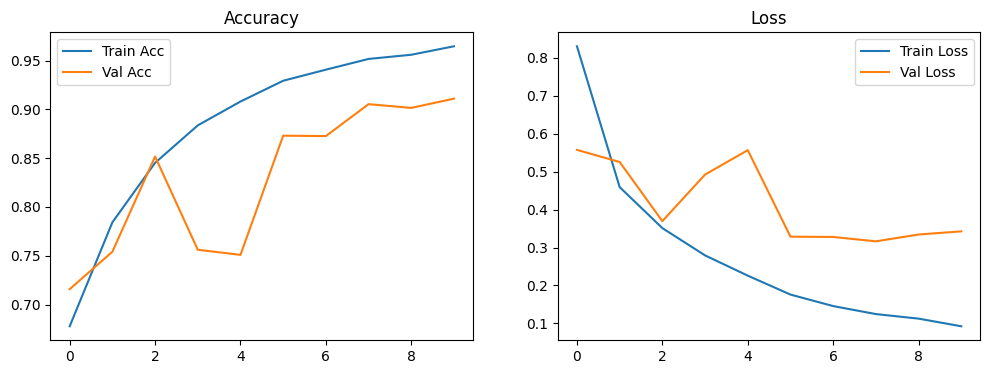

155/155 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9135 - loss: 0.3418
Validation Accuracy: 0.9110


In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

# Исправлено: используем val_batches вместо val_generator
loss_v, acc_v = model.evaluate(val_batches)
print(f'Validation Accuracy: {acc_v:.4f}')

In [11]:
# Оценка
val_loss_bn, val_acc_bn = model_bn.evaluate(val_batches)
print(f"\nМодель с BatchNormalization - Validation Accuracy: {val_acc_bn:.4f}")

NameError: name 'model_bn' is not defined